In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("powerplant_data.csv")

In [3]:
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
X = data.drop(columns = ["PE"])
y = data["PE"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
import torch
import torch.nn as nn
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,  dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)


In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=32)


Building ANN

In [10]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model = nn.Sequential(
            #1st hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
    
            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            #Output
            nn.Linear(6,1)
    )
    def forward(self,x):
        return self.model(x)
        

In [11]:
import torch.optim as optim

model = ANN()

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [12]:
epochs = 100
train_loss = []
val_loss = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb,yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = crietrion(output,yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss/len(train_loader)
    train_loss.append(epoch_train_loss)

    #validation
    #model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            output = model(xb)
            loss = crietrion(output,yb)
            running_val_loss += loss.item()

    epoch_test_loss = running_val_loss/len(test_loader)
    val_loss.append(epoch_test_loss)

    print(f"epoch{epoch+1}/{epochs} ==> train loss = {epoch_train_loss}, val loss = {epoch_test_loss}")

epoch1/100 ==> train loss = 205659.51354166667, val loss = 202994.35078125
epoch2/100 ==> train loss = 194088.01595052084, val loss = 179779.98020833332
epoch3/100 ==> train loss = 155573.92288411458, val loss = 126717.287109375
epoch4/100 ==> train loss = 92487.85463867188, val loss = 60048.11953125
epoch5/100 ==> train loss = 39105.90675455729, val loss = 24545.30890299479
epoch6/100 ==> train loss = 19275.524674479166, val loss = 15450.291634114583
epoch7/100 ==> train loss = 13673.613830566406, val loss = 11533.416162109375
epoch8/100 ==> train loss = 10263.97874552409, val loss = 8709.534708658854
epoch9/100 ==> train loss = 7771.176234944662, val loss = 6549.99462483724
epoch10/100 ==> train loss = 5742.5894114176435, val loss = 4765.553759765625
epoch11/100 ==> train loss = 4114.011330159506, val loss = 3353.547853597005
epoch12/100 ==> train loss = 2859.911730957031, val loss = 2285.7907775878907
epoch13/100 ==> train loss = 1936.161937713623, val loss = 1524.657861328125
epoch

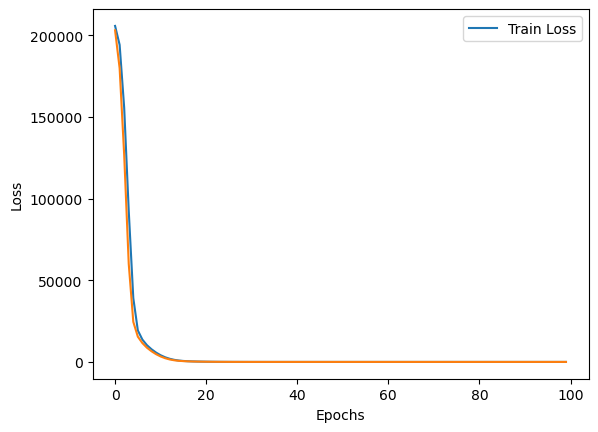

In [17]:
import matplotlib.pyplot as plt

data_df = pd.DataFrame({
    "train_loss": train_loss,
    "Val_loss" : val_loss}
)
plt.plot(data_df["train_loss"],label = "Train Loss")
plt.plot(data_df["Val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()